MRI → Synthetic CT Translation for Brain Imaging using Deep Learning

In [2]:
import os, glob, argparse, random
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr

Size

In [12]:
# check_cases.py
import os
def human(n): 
    for u in ['B','KB','MB','GB']: 
        if n<1024: return f"{n:.0f} {u}"; n/=1024
    return f"{n:.0f} TB"

BASE = r"E:\MRICT\Task1\actual data"
for case in sorted(os.listdir(BASE)):
    cdir = os.path.join(BASE, case)
    if not os.path.isdir(cdir): continue
    sizes = {}
    for f in ["mr.nii","mr.nii.gz","ct.nii","ct.nii.gz","mask.nii","mask.nii.gz"]:
        p = os.path.join(cdir, f)
        if os.path.exists(p): sizes[f] = os.path.getsize(p)
    print(case, "->", ", ".join(f"{k}:{human(v)}" for k,v in sizes.items()) or "NO FILES")


1BA001 -> mr.nii.gz:16966366 TB, ct.nii.gz:7360263 TB, mask.nii.gz:102644 TB
1BA005 -> mr.nii.gz:15908525 TB, ct.nii.gz:8929155 TB, mask.nii.gz:108501 TB
1BA012 -> mr.nii.gz:18250352 TB, ct.nii.gz:7637266 TB, mask.nii.gz:103044 TB
1BA014 -> mr.nii.gz:12157445 TB, ct.nii.gz:6709749 TB, mask.nii.gz:92513 TB
1BA022 -> mr.nii.gz:15908165 TB, ct.nii.gz:9184568 TB, mask.nii.gz:110394 TB
1BA032 -> mr.nii.gz:16869056 TB, ct.nii.gz:7167254 TB, mask.nii.gz:98769 TB
1BA040 -> mr.nii.gz:12713442 TB, ct.nii.gz:7082107 TB, mask.nii.gz:94984 TB
1BA054 -> mr.nii.gz:16144467 TB, ct.nii.gz:9292655 TB, mask.nii.gz:110764 TB
1BA058 -> mr.nii.gz:18059290 TB, ct.nii.gz:8254756 TB, mask.nii.gz:108849 TB
1BA075 -> mr.nii.gz:13253847 TB, ct.nii.gz:7846348 TB, mask.nii.gz:82667 TB
1BA076 -> mr.nii.gz:14292682 TB, ct.nii.gz:7261673 TB, mask.nii.gz:94429 TB
1BA082 -> mr.nii.gz:21394839 TB, ct.nii.gz:9062224 TB, mask.nii.gz:113178 TB
1BA085 -> mr.nii.gz:14121269 TB, ct.nii.gz:8142279 TB, mask.nii.gz:101247 TB
1BA0

sanity checker to find size of file 

In [14]:
# check_cases_clean.py
import os, glob

BASE = r"E:\MRICT\Task1\actual data"  # ← change if needed (D:\ ...)

UNITS = ["B","KB","MB","GB"]
def human_bytes(n: int) -> str:
    f = float(n)
    i = 0
    while f >= 1024 and i < len(UNITS)-1:
        f /= 1024.0
        i += 1
    return f"{f:.1f} {UNITS[i]}"

def find_first(case_dir: str, kind: str):
    # Prefer .nii.gz, then .nii; accept names containing the token
    pats = [f"{kind}.nii.gz", f"*{kind}*.nii.gz", f"{kind}.nii", f"*{kind}*.nii"]
    for pat in pats:
        hits = glob.glob(os.path.join(case_dir, pat))
        if hits:
            # pick the largest (sometimes multiple)
            hits.sort(key=lambda p: os.path.getsize(p), reverse=True)
            return hits[0]
    return None

if __name__ == "__main__":
    for case in sorted(os.listdir(BASE)):
        cdir = os.path.join(BASE, case)
        if not os.path.isdir(cdir): continue
        mr = find_first(cdir, "mr")
        ct = find_first(cdir, "ct")
        mk = find_first(cdir, "mask")
        def sz(p): return human_bytes(os.path.getsize(p)) if p and os.path.exists(p) else "NOT FOUND"
        print(f"{case} -> mr:{sz(mr)}, ct:{sz(ct)}, mask:{sz(mk)}")


1BA001 -> mr:16.2 MB, ct:7.0 MB, mask:100.2 KB
1BA005 -> mr:15.2 MB, ct:8.5 MB, mask:106.0 KB
1BA012 -> mr:17.4 MB, ct:7.3 MB, mask:100.6 KB
1BA014 -> mr:11.6 MB, ct:6.4 MB, mask:90.3 KB
1BA022 -> mr:15.2 MB, ct:8.8 MB, mask:107.8 KB
1BA032 -> mr:16.1 MB, ct:6.8 MB, mask:96.5 KB
1BA040 -> mr:12.1 MB, ct:6.8 MB, mask:92.8 KB
1BA054 -> mr:15.4 MB, ct:8.9 MB, mask:108.2 KB
1BA058 -> mr:17.2 MB, ct:7.9 MB, mask:106.3 KB
1BA075 -> mr:12.6 MB, ct:7.5 MB, mask:80.7 KB
1BA076 -> mr:13.6 MB, ct:6.9 MB, mask:92.2 KB
1BA082 -> mr:20.4 MB, ct:8.6 MB, mask:110.5 KB
1BA085 -> mr:13.5 MB, ct:7.8 MB, mask:98.9 KB
1BA091 -> mr:15.8 MB, ct:8.9 MB, mask:110.0 KB
1BA097 -> mr:17.6 MB, ct:7.4 MB, mask:104.9 KB
1BA100 -> mr:13.1 MB, ct:7.5 MB, mask:100.7 KB
1BA103 -> mr:17.4 MB, ct:7.8 MB, mask:105.2 KB
1BA105 -> mr:12.7 MB, ct:7.3 MB, mask:100.8 KB
1BA111 -> mr:17.8 MB, ct:8.2 MB, mask:110.7 KB
1BA116 -> mr:12.2 MB, ct:6.9 MB, mask:98.6 KB
1BA125 -> mr:12.2 MB, ct:7.1 MB, mask:97.3 KB
1BA131 -> mr:13.5 MB,

converting cases to png slices

In [15]:
# convert_cases_clean.py
import os, glob
from pathlib import Path
import numpy as np
import nibabel as nib
import imageio.v2 as iio

BASE = r"E:\MRICT\Task1\actual data"         # cases live here
OUT  = r"E:\MRICT\Task1\brain_slices"  # slices will be written here
MIN_BYTES = 1_000_000                  # treat files <1MB as invalid

def find_first(case_dir: str, kind: str):
    pats = [f"{kind}.nii.gz", f"*{kind}*.nii.gz", f"{kind}.nii", f"*{kind}*.nii"]
    hits = []
    for pat in pats:
        hits += glob.glob(os.path.join(case_dir, pat))
    hits = [h for h in hits if os.path.getsize(h) >= MIN_BYTES]
    hits.sort(key=lambda p: os.path.getsize(p), reverse=True)
    return hits[0] if hits else None

def norm_mri(x): return (x - x.min()) / (x.max() - x.min() + 1e-6)
def norm_ct(x):  return np.clip((x + 1000.0) / 3000.0, 0, 1)  # HU ~[-1000,2000] -> [0,1]

def convert_case(case_dir: str):
    case = os.path.basename(case_dir.rstrip("\\/"))
    mr_p, ct_p, mk_p = find_first(case_dir,"mr"), find_first(case_dir,"ct"), find_first(case_dir,"mask")
    if not mr_p or not ct_p:
        print(f"{case}: skip (missing MR/CT)"); return False

    print(f"{case}: converting …")
    mr = nib.load(mr_p).get_fdata().astype(np.float32)
    ct = nib.load(ct_p).get_fdata().astype(np.float32)
    mask = nib.load(mk_p).get_fdata().astype(np.float32) if mk_p else np.ones_like(mr, np.float32)

    mr, ct = norm_mri(mr), norm_ct(ct)

    mr_out   = Path(OUT)/case/"mr_crop";   mr_out.mkdir(parents=True, exist_ok=True)
    ct_out   = Path(OUT)/case/"ct_crop";   ct_out.mkdir(parents=True, exist_ok=True)
    mask_out = Path(OUT)/case/"mask_crop"; mask_out.mkdir(parents=True, exist_ok=True)

    nz = mr.shape[2]  # axial
    for i in range(nz):
        iio.imwrite(mr_out  / f"slice_{i:03d}.png", (mr[:,:,i]*255).astype(np.uint8))
        iio.imwrite(ct_out  / f"slice_{i:03d}.png", (ct[:,:,i]*255).astype(np.uint8))
        iio.imwrite(mask_out/ f"slice_{i:03d}.png", (mask[:,:,i]*255).astype(np.uint8))
    print(f"{case}: saved {nz} slices")
    return True

if __name__ == "__main__":
    ok = 0; total = 0
    for case in sorted(os.listdir(BASE)):
        cdir = os.path.join(BASE, case)
        if not os.path.isdir(cdir): continue
        total += 1
        ok += bool(convert_case(cdir))
    print(f"\nConverted {ok}/{total} cases -> {OUT}")


1BA001: converting …
1BA001: saved 204 slices
1BA005: converting …
1BA005: saved 206 slices
1BA012: converting …
1BA012: saved 197 slices
1BA014: converting …
1BA014: saved 174 slices
1BA022: converting …
1BA022: saved 211 slices
1BA032: converting …
1BA032: saved 177 slices
1BA040: converting …
1BA040: saved 189 slices
1BA054: converting …
1BA054: saved 224 slices
1BA058: converting …
1BA058: saved 197 slices
1BA075: converting …
1BA075: saved 207 slices
1BA076: converting …
1BA076: saved 197 slices
1BA082: converting …
1BA082: saved 219 slices
1BA085: converting …
1BA085: saved 207 slices
1BA091: converting …
1BA091: saved 209 slices
1BA097: converting …
1BA097: saved 202 slices
1BA100: converting …
1BA100: saved 189 slices
1BA103: converting …
1BA103: saved 210 slices
1BA105: converting …
1BA105: saved 201 slices
1BA111: converting …
1BA111: saved 220 slices
1BA116: converting …
1BA116: saved 198 slices
1BA125: converting …
1BA125: saved 200 slices
1BA131: converting …
1BA131: saved

plotting for confirm paring 

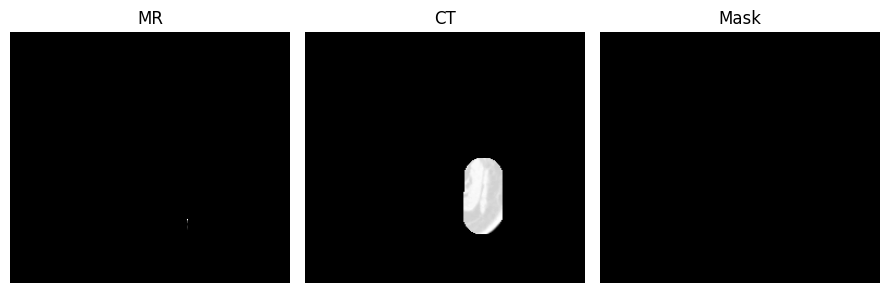

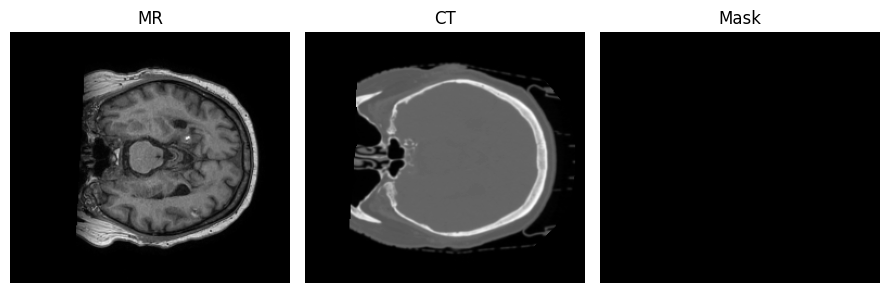

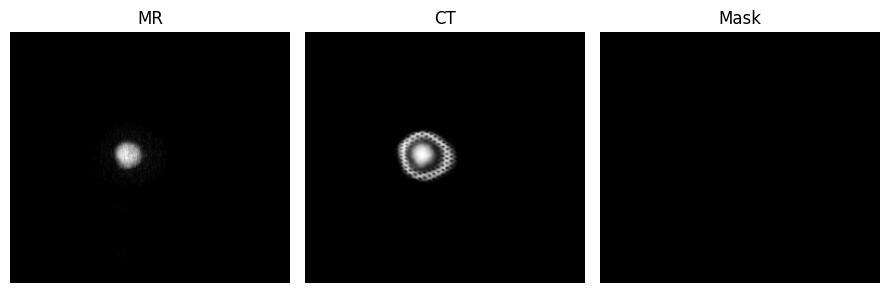

In [1]:
import glob, os
import matplotlib.pyplot as plt
import imageio.v2 as iio

case = r"E:\MRICT\Task1\brain_slices\1BA054"
m = sorted(glob.glob(os.path.join(case, "mr_crop", "slice_*.png")))
c = sorted(glob.glob(os.path.join(case, "ct_crop", "slice_*.png")))
k = sorted(glob.glob(os.path.join(case, "mask_crop", "slice_*.png")))

for i in [0, len(m)//2, -1]:
    mi, ci, ki = iio.imread(m[i])/255.0, iio.imread(c[i])/255.0, iio.imread(k[i])/255.0
    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1); plt.imshow(mi, cmap="gray"); plt.title("MR");   plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(ci, cmap="gray"); plt.title("CT");   plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(ki, cmap="gray"); plt.title("Mask"); plt.axis("off")
    plt.tight_layout(); plt.show()


helper code

In [30]:
# --- imports ---
import os, random
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch

# --- helpers you wrote (with 2 small fixes: ensure output dir + close fig) ---
def ensure_dir(p): Path(p).mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def imread_gray(p, size=None, is_mask=False):
    img = Image.open(p).convert("L")
    if size:
        img = img.resize((size, size),
                         resample=Image.NEAREST if is_mask else Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32)
    return arr / 255.0

def masked_l1(pred, target, mask=None):
    if mask is None:
        return torch.mean(torch.abs(pred - target))
    w = mask.clamp_min(0.0)
    num = torch.sum(torch.abs(pred - target) * w)
    den = torch.sum(w) + 1e-6
    return num / den

def save_heatmap(gt, pr, out_path, same_scale=True, show=False):
    gt = gt.astype(np.float32); pr = pr.astype(np.float32)
    diff = np.abs(gt - pr)

    if same_scale:
        vmin = float(min(gt.min(), pr.min()))
        vmax = float(max(gt.max(), pr.max()))
        if vmin == vmax:
            eps = 1e-6 if vmin == 0 else abs(vmin) * 1e-6
            vmin, vmax = vmin - eps, vmax + eps
    else:
        vmin = vmax = None

    out_path = Path(out_path)
    ensure_dir(out_path.parent)  # <<< make sure folder exists

    fig = plt.figure(figsize=(9, 3))
    try:
        plt.subplot(1, 3, 1); plt.imshow(gt, cmap="gray", vmin=vmin, vmax=vmax); plt.title("GT CT");   plt.axis("off")
        plt.subplot(1, 3, 2); plt.imshow(pr, cmap="gray", vmin=vmin, vmax=vmax); plt.title("Pred CT"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.imshow(diff, cmap="jet", vmin=0, vmax=np.percentile(diff, 99)); plt.title("|GT-Pred|"); plt.axis("off")
        plt.tight_layout()
        plt.savefig(out_path, dpi=150)
        if show: plt.show()  # only show if you’re in a notebook/GUI
    finally:
        plt.close(fig)       # <<< free the figure

    print(f"Saved figure to: {out_path}")
    return str(out_path)

# --- MINIMAL TEST (remove this when using real MRI/CT) ---
set_seed(0)
gt = np.random.rand(128, 128).astype(np.float32)
pr = gt + 0.05 * np.random.randn(128, 128).astype(np.float32)

save_heatmap(gt, pr, "outs/compare.png", same_scale=True, show=False)


Saved figure to: outs\compare.png


'outs\\compare.png'

In [31]:
from pathlib import Path
import numpy as np

mr = imread_gray(r"E:\MRICT\Task1\brain_slices\1BA054\mr_crop\slice_000.png")
ct = imread_gray(r"E:\MRICT\Task1\brain_slices\1BA054\ct_crop\slice_000.png")

save_heatmap(ct, mr, "outs/example.png", show=True)


Saved figure to: outs\example.png


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19612\2773458437.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  if show: plt.show()  # only show if you’re in a notebook/GUI


'outs\\example.png'

Left picture (GT) → This is your ground truth image (the real reference).

Middle picture (Pred) → This is your prediction image (what your model made).

Right picture (|GT − Pred|) → This shows the difference between the two:

Blue = almost the same

Yellow/Green/Red = where they don’t match

So:

If GT and Pred are very similar → the right image will be mostly dark blue.

If they are different → the right image will show lots of bright colors where the mismatch happens.

 In your example, GT and Pred are just random noisy images, so the difference map also looks noisy (lots of green/blue dots).

DATASET 

In [5]:
#  dataset 
# --- define imread_gray BEFORE the dataset ---
def imread_gray(p, size=None, is_mask=False):
    img = Image.open(p).convert("L")
    if size:
        img = img.resize((size, size), resample=Image.NEAREST if is_mask else Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32)
    return arr / 255.0


class BrainPairs(Dataset):
    """
    Expects: brain_dir/<case>/{mr_crop,ct_crop,mask_crop}/slice_XXX.png
    Merges all cases; filenames must match across mr/ct/(mask).
    """
    def __init__(self, brain_dir, img_size=256, use_mask=True, split="train",
                 val_ratio=0.2, seed=42):
        self.brain_dir = Path(brain_dir)
        self.size = img_size
        self.use_mask = use_mask
        pairs = []
        for case in sorted(os.listdir(brain_dir)):
            cdir = self.brain_dir / case
            mdir, cdir_ct = cdir/"mr_crop", cdir/"ct_crop"
            if not (mdir.is_dir() and cdir_ct.is_dir()): continue
            mlist = sorted(glob.glob(str(mdir/"*.png")))
            for mp in mlist:
                name = Path(mp).name
                cp = cdir_ct / name
                if cp.exists():
                    kp = cdir/"mask_crop"/name
                    pairs.append((str(mp), str(cp), str(kp)))
        # split
        random.Random(seed).shuffle(pairs)
        n_val = max(1, int(len(pairs)*val_ratio))
        self.files = pairs[n_val:] if split=="train" else pairs[:n_val]

    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        mp, cp, kp = self.files[idx]
        m = imread_gray(mp, self.size)           # input MRI
        c = imread_gray(cp, self.size)           # target CT
        m_t = torch.from_numpy(m[None,...])
        c_t = torch.from_numpy(c[None,...])
        if self.use_mask and os.path.exists(kp):
            k = imread_gray(kp, self.size)
            k_t = torch.from_numpy(k[None,...])
        else:
            k_t = torch.ones_like(m_t)
        return m_t, c_t, k_t

Train samples: 27648
Val samples: 6911
MRI shape: torch.Size([1, 256, 256]) min: 0.0 max: 0.8156862854957581
CT shape: torch.Size([1, 256, 256]) min: 0.0 max: 0.8666666746139526
Mask shape: torch.Size([1, 256, 256]) min: 1.0 max: 1.0


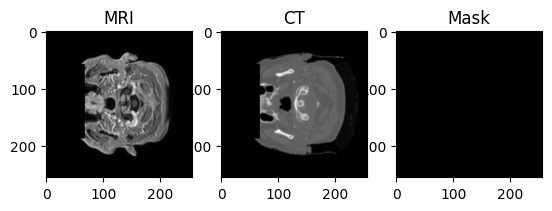

In [6]:
from torch.utils.data import DataLoader
%matplotlib inline


# put your dataset folder path here
BRAIN_DIR = r"E:\MRICT\Task1\brain_slices"

# make dataset
train_ds = BrainPairs(BRAIN_DIR, img_size=256, split="train")
val_ds   = BrainPairs(BRAIN_DIR, img_size=256, split="val")

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))

# show one sample
m, c, k = train_ds[0]   # MRI, CT, Mask
print("MRI shape:", m.shape, "min:", m.min().item(), "max:", m.max().item())
print("CT shape:", c.shape, "min:", c.min().item(), "max:", c.max().item())
print("Mask shape:", k.shape, "min:", k.min().item(), "max:", k.max().item())

# see them as images
import matplotlib.pyplot as plt
plt.subplot(1,3,1); plt.imshow(m[0], cmap="gray"); plt.title("MRI")
plt.subplot(1,3,2); plt.imshow(c[0], cmap="gray"); plt.title("CT")
plt.subplot(1,3,3); plt.imshow(k[0], cmap="gray"); plt.title("Mask")
plt.show()


MODEL

In [7]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """(Conv2D → ReLU) × 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet2D(nn.Module):
    """Tiny U-Net for MRI→CT"""
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        # Downsampling path
        self.d1 = DoubleConv(in_ch, base);   self.p1 = nn.MaxPool2d(2)
        self.d2 = DoubleConv(base, base*2);  self.p2 = nn.MaxPool2d(2)
        self.d3 = DoubleConv(base*2, base*4);self.p3 = nn.MaxPool2d(2)
        self.b  = DoubleConv(base*4, base*8)

        # Upsampling path
        self.u3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.c3 = DoubleConv(base*8, base*4)

        self.u2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.c2 = DoubleConv(base*4, base*2)

        self.u1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.c1 = DoubleConv(base*2, base)

        # Output layer
        self.out = nn.Sequential(
            nn.Conv2d(base, out_ch, kernel_size=1),
            nn.Sigmoid()   # scale to [0,1] since CT images are normalized
        )

    def forward(self, x):
        # Down
        x1 = self.d1(x)
        x2 = self.d2(self.p1(x1))
        x3 = self.d3(self.p2(x2))
        xb = self.b(self.p3(x3))

        # Up
        x = self.u3(xb); x = self.c3(torch.cat([x, x3], dim=1))
        x = self.u2(x);  x = self.c2(torch.cat([x, x2], dim=1))
        x = self.u1(x);  x = self.c1(torch.cat([x, x1], dim=1))

        return self.out(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet2D().to(device)

# dummy input [batch=1, channels=1, height=128, width=128]
x = torch.randn(1, 1, 128, 128).to(device)
y = model(x)
print("Output shape:", y.shape)



Output shape: torch.Size([1, 1, 128, 128])


In [10]:
from torch.optim import Adam
from torch.utils.data import DataLoader
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
import numpy as np
from pathlib import Path

def ensure_dir(p):
    Path(p).mkdir(parents=True, exist_ok=True)

# --- training loop ---
def train_and_eval(brain_dir, out_dir="runs_brain", size=128, epochs=5, bs=4, lr=1e-4):
    ensure_dir(out_dir)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # datasets
    train_ds = BrainPairs(brain_dir, img_size=size, split="train")
    val_ds   = BrainPairs(brain_dir, img_size=size, split="val")
    train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)
    val_dl   = DataLoader(val_ds, batch_size=1, shuffle=False)

    print(f"train samples: {len(train_ds)} | val samples: {len(val_ds)}")

    # model + optimizer
    model = UNet2D().to(device)
    opt = Adam(model.parameters(), lr=lr)
    ckpt = Path(out_dir) / "best_unet2d.pth"
    best_val = 1e9

    # training epochs
    for ep in range(1, epochs+1):
        model.train(); run_loss = 0.0
        for m,c,k in train_dl:
            m,c,k = m.to(device), c.to(device), k.to(device)
            p = model(m)
            loss = masked_l1(p, c, k)
            opt.zero_grad(); loss.backward(); opt.step()
            run_loss += loss.item()
        train_loss = run_loss / len(train_dl)

        # validation
        model.eval(); val_loss = 0.0
        with torch.no_grad():
            for m,c,k in val_dl:
                m,c,k = m.to(device), c.to(device), k.to(device)
                val_loss += masked_l1(model(m), c, k).item()
        val_loss /= len(val_dl)

        print(f"[{ep:03d}] train L1={train_loss:.4f} | val L1={val_loss:.4f}")
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), ckpt)
            print("   saved:", ckpt)

    # evaluation metrics on val set
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    ssim_sum=psnr_sum=mae_sum=mse_sum=0.0; n=0
    ex_dir = Path(out_dir)/"eval"; ensure_dir(ex_dir)

    with torch.no_grad():
        for i,(m,c,k) in enumerate(val_dl):
            p = model(m.to(device)).cpu()
            gt = c[0,0].numpy(); pr = p[0,0].numpy()

            ssim_sum += ssim(gt, pr, data_range=1.0)
            psnr_sum += psnr(gt, pr, data_range=1.0)
            mae_sum  += float(np.mean(np.abs(gt-pr)))
            mse_sum  += float(np.mean((gt-pr)**2))

            if i < 4:  # save first few comparisons
                save_heatmap(gt, pr, str(ex_dir/f"diff_{i:03d}.png"))
            n += 1

    metrics = {"SSIM": ssim_sum/n, "PSNR": psnr_sum/n, "MAE": mae_sum/n, "MSE": mse_sum/n}
    print("Validation metrics:", metrics)
    return metrics
BRAIN_DIR = r"E:\MRICT\Task1\brain_slices"
metrics = train_and_eval(BRAIN_DIR, size=128, epochs=1, bs=4)  # 1 epoch just to test



Device: cpu
train samples: 27648 | val samples: 6911


NameError: name 'masked_l1' is not defined

In [11]:
# ==== ONE-CELL MINIMAL TRAIN+EVAL (runs ~fast) ====
import os, glob, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from PIL import Image
import matplotlib.pyplot as plt

# ---------- helpers ----------
def ensure_dir(p): Path(p).mkdir(parents=True, exist_ok=True)

def imread_gray(p, size=None, is_mask=False):
    img = Image.open(p).convert("L")
    if size:
        img = img.resize((size, size), resample=Image.NEAREST if is_mask else Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32)
    return arr / 255.0

def masked_l1(pred, target, mask=None):
    if mask is None:
        return torch.mean(torch.abs(pred - target))
    w = mask.clamp_min(0.0)
    num = torch.sum(torch.abs(pred - target) * w)
    den = torch.sum(w) + 1e-6
    return num / den

def save_heatmap(gt, pr, out_path):
    diff = np.abs(gt - pr)
    ensure_dir(Path(out_path).parent)
    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1); plt.imshow(gt, cmap="gray"); plt.title("GT");   plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(pr, cmap="gray"); plt.title("Pred"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(diff, cmap="jet"); plt.title("|GT-Pred|"); plt.axis("off")
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.close()

# ---------- dataset ----------
class BrainPairs(Dataset):
    """ Expects: brain_dir/<case>/{mr_crop,ct_crop,mask_crop}/slice_XXX.png """
    def __init__(self, brain_dir, img_size=128, use_mask=True, split="train",
                 val_ratio=0.2, seed=42):
        self.size = img_size
        self.use_mask = use_mask
        pairs = []
        for case in sorted(os.listdir(brain_dir)):
            cdir = Path(brain_dir)/case
            mdir, ctdir, mkdir = cdir/"mr_crop", cdir/"ct_crop", cdir/"mask_crop"
            if not (mdir.is_dir() and ctdir.is_dir()): 
                continue
            mr_names = {p.name for p in Path(mdir).glob("*.png")}
            ct_names = {p.name for p in Path(ctdir).glob("*.png")}
            for name in sorted(mr_names & ct_names):
                pairs.append((str(mdir/name), str(ctdir/name), str(mkdir/name)))
        random.Random(seed).shuffle(pairs)
        n_val = max(1, int(len(pairs)*val_ratio))
        self.files = pairs[n_val:] if split=="train" else pairs[:n_val]

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        mp, cp, kp = self.files[idx]
        m = imread_gray(mp, self.size, is_mask=False)
        c = imread_gray(cp, self.size, is_mask=False)
        m_t = torch.from_numpy(m[None, ...])
        c_t = torch.from_numpy(c[None, ...])
        if self.use_mask and os.path.exists(kp):
            k = imread_gray(kp, self.size, is_mask=True)
            k_t = torch.from_numpy(k[None, ...])
        else:
            k_t = torch.ones_like(m_t)
        return m_t, c_t, k_t

# ---------- model ----------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.d1=DoubleConv(in_ch,base); self.p1=nn.MaxPool2d(2)
        self.d2=DoubleConv(base,base*2); self.p2=nn.MaxPool2d(2)
        self.d3=DoubleConv(base*2,base*4); self.p3=nn.MaxPool2d(2)
        self.b =DoubleConv(base*4,base*8)
        self.u3=nn.ConvTranspose2d(base*8,base*4,2,2); self.c3=DoubleConv(base*8,base*4)
        self.u2=nn.ConvTranspose2d(base*4,base*2,2,2); self.c2=DoubleConv(base*4,base*2)
        self.u1=nn.ConvTranspose2d(base*2,base,2,2);   self.c1=DoubleConv(base*2,base)
        self.out=nn.Sequential(nn.Conv2d(base,out_ch,1), nn.Sigmoid())
    def forward(self,x):
        x1=self.d1(x); x2=self.d2(self.p1(x1)); x3=self.d3(self.p2(x2)); xb=self.b(self.p3(x3))
        x=self.u3(xb); x=self.c3(torch.cat([x,x3],1))
        x=self.u2(x);  x=self.c2(torch.cat([x,x2],1))
        x=self.u1(x);  x=self.c1(torch.cat([x,x1],1))
        return self.out(x)

# ---------- training + eval ----------
def train_and_eval(brain_dir, out_dir="runs_brain", size=128, epochs=1, bs=4, lr=1e-4):
    ensure_dir(out_dir)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    train_ds = BrainPairs(brain_dir, img_size=size, split="train")
    val_ds   = BrainPairs(brain_dir, img_size=size, split="val")
    train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=0)
    val_dl   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)

    print(f"train samples: {len(train_ds)} | val samples: {len(val_ds)}")

    model = UNet2D().to(device)
    opt = Adam(model.parameters(), lr=lr)
    ckpt = Path(out_dir)/"best_unet2d.pth"
    best = float("inf")

    for ep in range(1, epochs+1):
        model.train(); run=0.0
        for m,c,k in train_dl:
            m,c,k = m.to(device), c.to(device), k.to(device)
            p = model(m)
            loss = masked_l1(p, c, k)
            opt.zero_grad(); loss.backward(); opt.step()
            run += loss.item()
        tr = run/max(1,len(train_dl))

        model.eval(); v=0.0
        with torch.no_grad():
            for m,c,k in val_dl:
                m,c,k = m.to(device), c.to(device), k.to(device)
                v += masked_l1(model(m), c, k).item()
        v/=max(1,len(val_dl))
        print(f"[{ep:03d}] train L1={tr:.4f} | val L1={v:.4f}")
        if v < best:
            best = v; torch.save(model.state_dict(), ckpt); print("   saved:", ckpt)

    # --- evaluation + a few images ---
    model.load_state_dict(torch.load(ckpt, map_location=device)); model.eval()
    ssim_sum=psnr_sum=mae_sum=mse_sum=0.0; n=0
    ex_dir = Path(out_dir)/"eval"; ensure_dir(ex_dir)
    with torch.no_grad():
        for i,(m,c,k) in enumerate(val_dl):
            p = model(m.to(device)).cpu()
            gt = c[0,0].numpy().astype(np.float32)
            pr = p[0,0].numpy().astype(np.float32)
            ssim_sum += ssim(gt, pr, data_range=1.0)
            psnr_sum += psnr(gt, pr, data_range=1.0)
            mae_sum  += float(np.mean(np.abs(gt-pr)))
            mse_sum  += float(np.mean((gt-pr)**2))
            if i < 4:
                save_heatmap(gt, pr, str(ex_dir/f"diff_{i:03d}.png"))
            n += 1
    metrics = {"SSIM": ssim_sum/n, "PSNR": psnr_sum/n, "MAE": mae_sum/n, "MSE": mse_sum/n}
    print("Validation metrics:", metrics)
    return metrics

# -------- run quick test --------
BRAIN_DIR = r"E:\MRICT\Task1\brain_slices"   # <- your dataset
metrics = train_and_eval(BRAIN_DIR, size=128, epochs=1, bs=4)


Device: cpu
train samples: 27648 | val samples: 6911
[001] train L1=0.1288 | val L1=0.1266
   saved: runs_brain\best_unet2d.pth
Validation metrics: {'SSIM': np.float64(0.5069800505229952), 'PSNR': np.float64(14.027340893167619), 'MAE': 0.12661275418998416, 'MSE': 0.05132648193115166}
